In [1]:
import pandas as pd
import numpy as np
import os
import re
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_df = pd.read_csv(
    '/content/drive/MyDrive/Game_Review_NLP/train_reviews_v2.csv'
)

test_df = pd.read_csv(
    '/content/drive/MyDrive/Game_Review_NLP/test_reviews_v2.csv'
)

unseen_df = pd.read_csv(
    '/content/drive/MyDrive/Game_Review_NLP/unseen_reviews_v2.csv'
)

print("Training:", train_df.shape)
print("Testing :", test_df.shape)
print("Unseen  :", unseen_df.shape)

Training: (74665, 19)
Testing : (18900, 19)
Unseen  : (2660, 19)


In [4]:
print("TRAINING")
print(train_df['sentiment_final'].value_counts())

print("\nTESTING")
print(test_df['sentiment_final'].value_counts())

print("\nUNSEEN")
print(unseen_df['sentiment_final'].value_counts())

TRAINING
sentiment_final
positive    66274
neutral      8037
negative      354
Name: count, dtype: int64

TESTING
sentiment_final
positive    16775
neutral      2053
negative       72
Name: count, dtype: int64

UNSEEN
sentiment_final
positive    2377
neutral      270
negative      13
Name: count, dtype: int64


In [5]:
print(train_df['review_text'].isna().sum())
print(test_df['review_text'].isna().sum())
print(unseen_df['review_text'].isna().sum())

0
0
0


In [6]:
train_df = train_df.dropna(
    subset=['review_text', 'sentiment_final']
).copy()

test_df = test_df.dropna(
    subset=['review_text', 'sentiment_final']
).copy()

unseen_df = unseen_df.dropna(
    subset=['review_text', 'sentiment_final']
).copy()

print("Training:", len(train_df))
print("Testing :", len(test_df))
print("Unseen  :", len(unseen_df))

Training: 74665
Testing : 18900
Unseen  : 2660


In [7]:
X_train = train_df['review_text'].astype(str)
y_train = train_df['sentiment_final']

X_test = test_df['review_text'].astype(str)
y_test = test_df['sentiment_final']

X_unseen = unseen_df['review_text'].astype(str)
y_unseen = unseen_df['sentiment_final']

In [8]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=200000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (74665, 200000)
Testing TF-IDF shape : (18900, 200000)


Train Logistic Regression

In [9]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("✓ Logistic Regression trained.")

✓ Logistic Regression trained.


Evaluation

In [10]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.0833    0.0139    0.0238        72
     neutral     0.3196    0.5709    0.4098      2053
    positive     0.9411    0.8539    0.8954     16775

    accuracy                         0.8199     18900
   macro avg     0.4480    0.4796    0.4430     18900
weighted avg     0.8703    0.8199    0.8393     18900



In [11]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_macro_precision = precision_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

lr_macro_recall = recall_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

lr_macro_f1 = f1_score(
    y_test,
    y_pred_lr,
    average='macro',
    zero_division=0
)

print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy       : {lr_accuracy:.4f}")
print(f"Macro Precision: {lr_macro_precision:.4f}")
print(f"Macro Recall   : {lr_macro_recall:.4f}")
print(f"Macro F1       : {lr_macro_f1:.4f}")

LOGISTIC REGRESSION
Accuracy       : 0.8199
Macro Precision: 0.4480
Macro Recall   : 0.4796
Macro F1       : 0.4430


Train Linear SVM

In [12]:
svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=3000
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("✓ Linear SVM trained.")

✓ Linear SVM trained.


Evaluate SVM

In [13]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print(
    classification_report(
        y_test,
        y_pred_svm,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000        72
     neutral     0.4354    0.2957    0.3522      2053
    positive     0.9153    0.9551    0.9348     16775

    accuracy                         0.8798     18900
   macro avg     0.4503    0.4169    0.4290     18900
weighted avg     0.8597    0.8798    0.8680     18900



In [14]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_macro_precision = precision_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

svm_macro_recall = recall_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

svm_macro_f1 = f1_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

print("LINEAR SVM")
print("=" * 50)
print(f"Accuracy       : {svm_accuracy:.4f}")
print(f"Macro Precision: {svm_macro_precision:.4f}")
print(f"Macro Recall   : {svm_macro_recall:.4f}")
print(f"Macro F1       : {svm_macro_f1:.4f}")

LINEAR SVM
Accuracy       : 0.8798
Macro Precision: 0.4503
Macro Recall   : 0.4169
Macro F1       : 0.4290


Compare the two models

In [15]:
comparison = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Balanced Linear SVM'
    ],
    'Accuracy': [
        lr_accuracy,
        svm_accuracy
    ],
    'Macro Precision': [
        lr_macro_precision,
        svm_macro_precision
    ],
    'Macro Recall': [
        lr_macro_recall,
        svm_macro_recall
    ],
    'Macro F1': [
        lr_macro_f1,
        svm_macro_f1
    ]
})

display(
    comparison.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}'
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Balanced Logistic Regression,0.8199,0.4480,0.4796,0.4430
1,Balanced Linear SVM,0.8798,0.4503,0.4169,0.4290


negative class

In [16]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_lr,
        labels=['negative', 'neutral', 'positive'],
        digits=4,
        zero_division=0
    )
)

print("\nLINEAR SVM")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=['negative', 'neutral', 'positive'],
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    negative     0.0833    0.0139    0.0238        72
     neutral     0.3196    0.5709    0.4098      2053
    positive     0.9411    0.8539    0.8954     16775

    accuracy                         0.8199     18900
   macro avg     0.4480    0.4796    0.4430     18900
weighted avg     0.8703    0.8199    0.8393     18900


LINEAR SVM
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000        72
     neutral     0.4354    0.2957    0.3522      2053
    positive     0.9153    0.9551    0.9348     16775

    accuracy                         0.8798     18900
   macro avg     0.4503    0.4169    0.4290     18900
weighted avg     0.8597    0.8798    0.8680     18900



confusion matrices

Logistic Regression

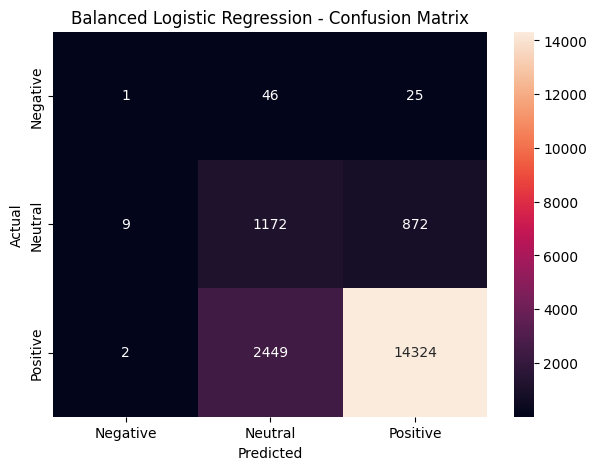

In [17]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced Logistic Regression - Confusion Matrix')
plt.show()

SVM

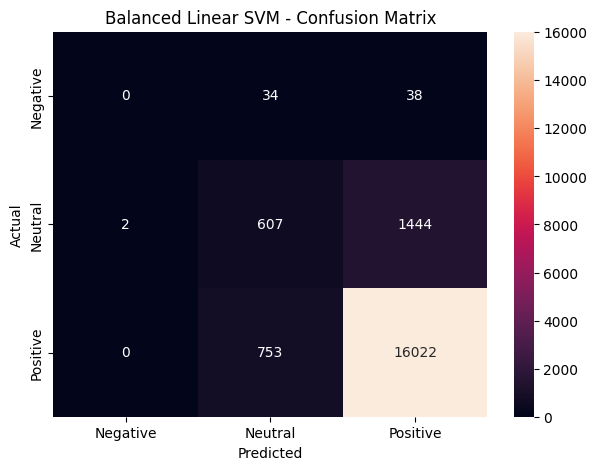

In [18]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Balanced Linear SVM - Confusion Matrix')
plt.show()

Create an oversampled training dataset

In [19]:
from sklearn.utils import resample

# Separate classes
train_positive = train_df[
    train_df['sentiment_final'] == 'positive'
]

train_neutral = train_df[
    train_df['sentiment_final'] == 'neutral'
]

train_negative = train_df[
    train_df['sentiment_final'] == 'negative'
]

print("Original training classes:")
print("Positive:", len(train_positive))
print("Neutral :", len(train_neutral))
print("Negative:", len(train_negative))

Original training classes:
Positive: 66274
Neutral : 8037
Negative: 354


Oversample neutral and negative

In [20]:
TARGET_NEUTRAL = 16000
TARGET_NEGATIVE = 16000

In [21]:
neutral_oversampled = resample(
    train_neutral,
    replace=True,
    n_samples=TARGET_NEUTRAL,
    random_state=42
)

negative_oversampled = resample(
    train_negative,
    replace=True,
    n_samples=TARGET_NEGATIVE,
    random_state=42
)

In [22]:
positive_kept = train_positive.copy()

In [23]:
train_oversampled = pd.concat(
    [
        positive_kept,
        neutral_oversampled,
        negative_oversampled
    ],
    ignore_index=True
)

# Shuffle
train_oversampled = train_oversampled.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [24]:
print("OVERSAMPLED TRAINING DATA")
print("=" * 50)

print(
    train_oversampled['sentiment_final'].value_counts()
)

OVERSAMPLED TRAINING DATA
sentiment_final
positive    66274
negative    16000
neutral     16000
Name: count, dtype: int64


Create the new training text

In [25]:
X_train_over = train_oversampled[
    'review_text'
].astype(str)

y_train_over = train_oversampled[
    'sentiment_final'
]

Create a new TF-IDF representation

In [26]:
tfidf_over = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=200000
)

X_train_over_tfidf = tfidf_over.fit_transform(
    X_train_over
)

X_test_over_tfidf = tfidf_over.transform(
    X_test
)

print(
    "Training TF-IDF:",
    X_train_over_tfidf.shape
)

print(
    "Testing TF-IDF:",
    X_test_over_tfidf.shape
)

Training TF-IDF: (98274, 200000)
Testing TF-IDF: (18900, 200000)


Train Logistic Regression WITHOUT class balancing

In [27]:
lr_oversampled = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_oversampled.fit(
    X_train_over_tfidf,
    y_train_over
)

print("✓ Oversampled Logistic Regression trained.")

✓ Oversampled Logistic Regression trained.


In [28]:
y_pred_over = lr_oversampled.predict(
    X_test_over_tfidf
)

print(
    classification_report(
        y_test,
        y_pred_over,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000        72
     neutral     0.5088    0.1836    0.2699      2053
    positive     0.9052    0.9796    0.9409     16775

    accuracy                         0.8894     18900
   macro avg     0.4713    0.3877    0.4036     18900
weighted avg     0.8587    0.8894    0.8644     18900



Evaluation

In [29]:
over_accuracy = accuracy_score(
    y_test,
    y_pred_over
)

over_precision = precision_score(
    y_test,
    y_pred_over,
    average='macro',
    zero_division=0
)

over_recall = recall_score(
    y_test,
    y_pred_over,
    average='macro',
    zero_division=0
)

over_f1 = f1_score(
    y_test,
    y_pred_over,
    average='macro',
    zero_division=0
)

print("OVERSAMPLED LOGISTIC REGRESSION")
print("=" * 50)

print(f"Accuracy       : {over_accuracy:.4f}")
print(f"Macro Precision: {over_precision:.4f}")
print(f"Macro Recall   : {over_recall:.4f}")
print(f"Macro F1       : {over_f1:.4f}")

OVERSAMPLED LOGISTIC REGRESSION
Accuracy       : 0.8894
Macro Precision: 0.4713
Macro Recall   : 0.3877
Macro F1       : 0.4036


Confusion matrix

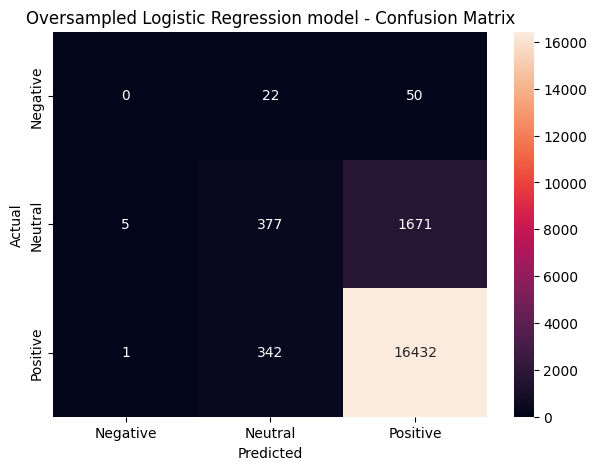

In [30]:
over_lr = confusion_matrix(
    y_test,
    y_pred_over,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    over_lr,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Oversampled Logistic Regression model - Confusion Matrix')
plt.show()

Negative Performance

In [31]:
print(
    classification_report(
        y_test,
        y_pred_over,
        labels=['negative', 'neutral', 'positive'],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000        72
     neutral     0.5088    0.1836    0.2699      2053
    positive     0.9052    0.9796    0.9409     16775

    accuracy                         0.8894     18900
   macro avg     0.4713    0.3877    0.4036     18900
weighted avg     0.8587    0.8894    0.8644     18900

